In [ ]:
pip install pillow


In [ ]:
from PIL import Image

In [ ]:
image = Image.open ("/content/drive/MyDrive/AI ML/Data/lena_gray.gif")
image
print ( " Image Format : " , image.format )
print ( " Image Size : " , image.size )
print ( " Image Mode : " , image.mode )

 Image Format :  GIF
 Image Size :  (512, 512)
 Image Mode :  P


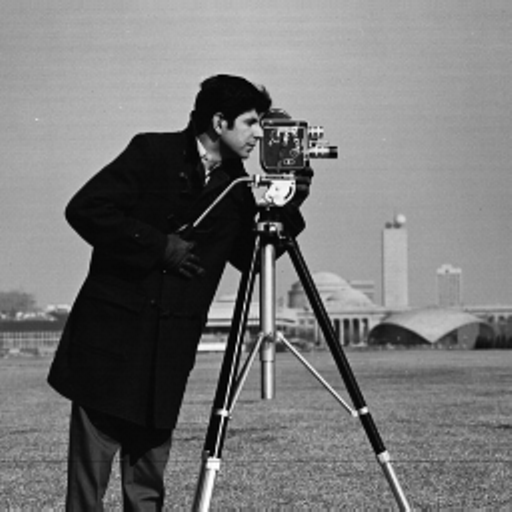

In [ ]:
image = Image.open ("/content/drive/MyDrive/AI ML/Data/cameraman.png")
image


In [ ]:
print ( " Image Format : " , image.format )
print ( " Image Size : " , image.size )
print ( " Image Mode : " , image.mode )

 Image Format :  PNG
 Image Size :  (512, 512)
 Image Mode :  L


In [ ]:
width , height = image.size
channels = len( image . getbands () )
print ( f" Image shape (RGB): ({ height } , { width } , { channels})")
image= width*height*1
print ( f" Image size (RGB): { image}")

 Image shape (RGB): (512 , 512 , 1)
 Image size (RGB): 262144


In [ ]:
import numpy as np

imagecolored= np . array ( image )
print (" Shape of the image array :", imagecolored.shape )

 Shape of the image array : ()


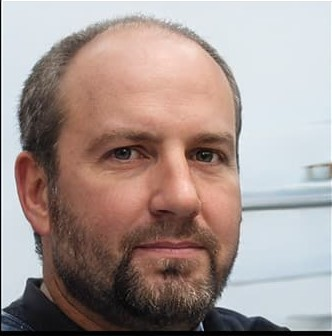

In [ ]:
cimage= Image.open ("/content/drive/MyDrive/AI ML/Data/hell.jpg")
cimage

In [ ]:
image_array_colored = np . array ( cimage )
print (" Shape of the image array :", image_array_colored.shape)

 Shape of the image array : (336, 332, 3)


In [ ]:
red_channel = image_array_colored [: , : , 0] # Red channel
print( red_channel )

[[ 26 171 252 ... 254 252 254]
 [ 21 179 250 ... 225 225 231]
 [ 10 189 252 ... 225 232 249]
 ...
 [  1   0   6 ...  10   9   7]
 [  0   0   8 ...   1   1   1]
 [ 10   7   7 ...  10   9  11]]


In [ ]:
green_channel = image_array_colored [: , : , 1] # Green
print (green_channel)

[[ 27 172 255 ... 255 253 255]
 [ 22 180 254 ... 226 226 232]
 [ 11 190 255 ... 229 233 250]
 ...
 [  1   0   7 ...  10   9   7]
 [  0   0   8 ...   0   0   0]
 [ 11   8   7 ...   8   8  10]]


In [ ]:
blue_channel = image_array_colored [: , : , 2] # Blue channel
print ( blue_channel )

[[ 29 174 255 ... 255 255 255]
 [ 24 182 255 ... 230 230 236]
 [ 13 192 255 ... 232 237 254]
 ...
 [  1   0   9 ...  10   9   7]
 [  0   0   8 ...   0   0   0]
 [  6   3   7 ...   9   6   8]]


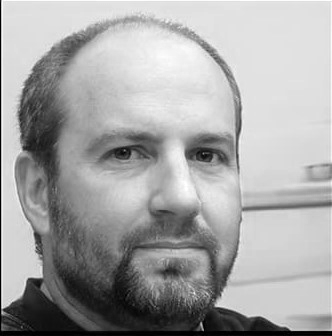

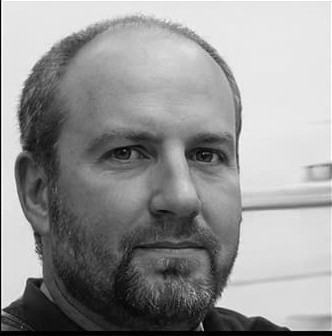

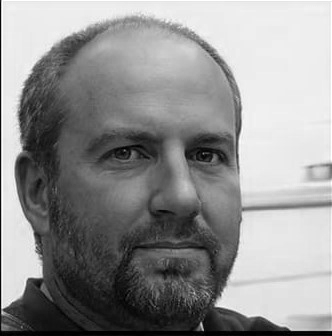

In [ ]:
r , g , b = cimage . split ()
display ( r )
display ( g )
display ( b )

In [ ]:
row_100 = image_array_colored [100 , : , :]
col_50 = image_array_colored [: , 50 , :]
pixel = image_array_colored [10 , 20 , :]

print(row_100)
col_50
pixel

[[  0   5   9]
 [189 194 198]
 [242 249 255]
 [221 228 234]
 [217 226 233]
 [217 226 233]
 [217 227 236]
 [217 227 236]
 [219 229 238]
 [218 228 237]
 [217 227 236]
 [216 226 235]
 [216 227 233]
 [215 226 232]
 [210 221 227]
 [204 214 223]
 [201 211 221]
 [200 210 219]
 [181 190 195]
 [161 166 169]
 [120 124 123]
 [ 80  81  76]
 [ 64  60  57]
 [ 84  79  75]
 [109 101  98]
 [123 115 112]
 [112 102 101]
 [ 89  79  78]
 [ 63  55  52]
 [ 69  61  58]
 [ 66  61  57]
 [ 68  63  59]
 [ 68  59  54]
 [ 62  53  48]
 [ 68  58  56]
 [ 76  66  64]
 [ 87  76  74]
 [ 78  67  65]
 [ 74  62  62]
 [ 71  59  59]
 [ 60  46  45]
 [ 63  49  48]
 [ 69  55  54]
 [ 77  63  60]
 [ 84  69  66]
 [ 84  69  64]
 [ 77  62  57]
 [ 70  55  50]
 [ 82  65  58]
 [ 83  66  59]
 [ 84  67  59]
 [ 82  65  57]
 [ 83  65  55]
 [ 92  72  63]
 [104  82  71]
 [109  85  73]
 [111  85  72]
 [114  88  73]
 [121  92  78]
 [131 102  86]
 [124  93  75]
 [131  98  81]
 [132  99  82]
 [135 100  81]
 [141 104  85]
 [143 105  84]
 [145 107 

array([223, 230, 236], dtype=uint8)

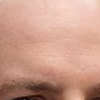

In [ ]:
left = 100
upper = 50
right = 200
lower = 150

# Create a bounding box tuple
bbox = (left, upper, right, lower)

# Apply the crop method to the PIL Image object (cimage), not the numpy array
cropped_image = cimage.crop(bbox)
display(cropped_image)


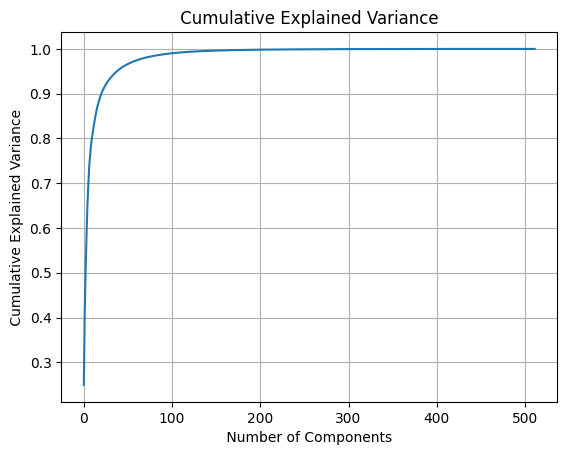

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
image = Image.open ("/content/drive/MyDrive/AI ML/Data/lena_gray.gif")
# Convert the image to grayscale before converting to numpy array
# This ensures image_array has only two dimensions (height, width)
image_gray = image.convert('L')
image_array = np . array ( image_gray )
height , width = image_array . shape
data = image_array . reshape ( height , width )
mean = np . mean ( data , axis =0)
centered_data = data - mean
cov_matrix = np . cov ( centered_data , rowvar = False )
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]
compressed_data = np . dot ( centered_data , components )
decompressed_data = np . dot ( compressed_data , components . T ) +mean

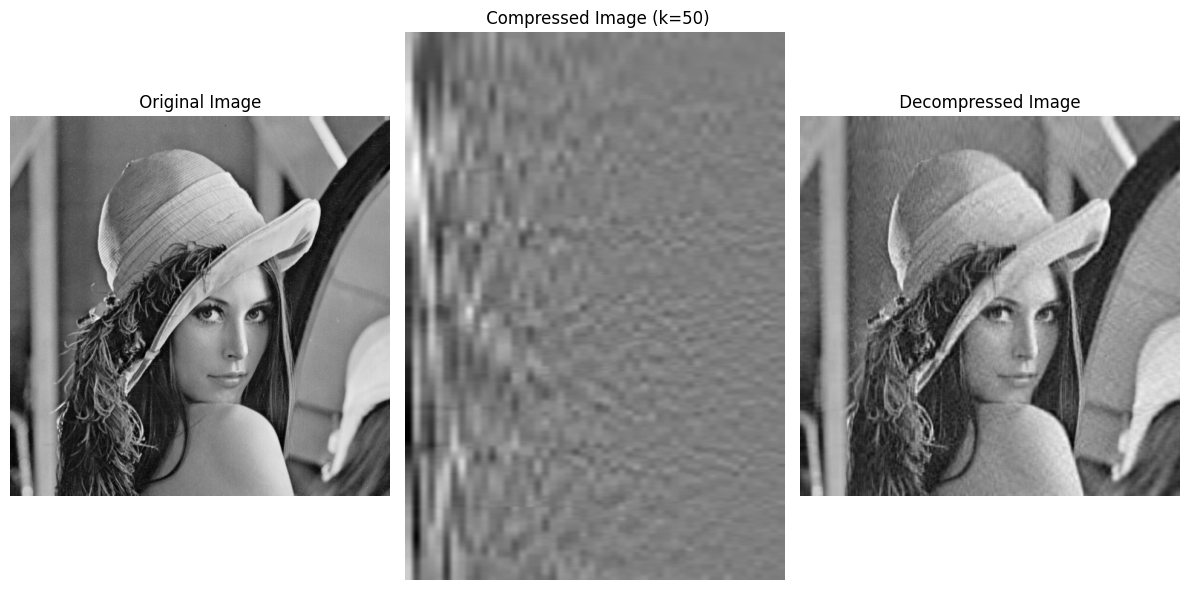

In [ ]:
plt . figure ( figsize =(12 , 6) )
# Original Image
plt . subplot (1 , 3 , 1)
plt . imshow ( image_array , cmap ="gray")
plt . title (" Original Image ")
plt . axis ("off")
 # Compressed Representation
plt . subplot (1 , 3 , 2)
plt . imshow ( compressed_data , cmap ="gray", aspect ="auto")
plt . title ( f" Compressed Image (k={k})")
plt . axis ("off")
# Decompressed Image
plt . subplot (1 , 3 , 3)
plt . imshow ( decompressed_data , cmap ="gray")
plt . title (" Decompressed Image ")
plt . axis ("off")
plt . tight_layout ()
plt . show ()